# RuIntona — Speech Emotion Recognition (Demo)

Демонстрация инференса обученных моделей на одном примере:
**аудио** (mel-спектрограмма → CNN-BiLSTM) + **текст** (RuBERT) → soft-voting (**late-fusion**).

**Данные:** `data/001ce26c07c20eaa0d666b824c6c6924.wav` (4 c, 16 кГц), текст из `data/example1.json`.

**Модели** (веса в `ruintona/my_experiments/checkpoints/`):

| Модель | Вход | Архитектура |
|---|---|---|
| `audio` | mel-спектрограмма `(1, 64, T)` | CNN-BiLSTM |
| `text` | токены RuBERT | RuBERT + head |
| `late-fusion` | аудио + текст | `alpha·P_audio + (1−alpha)·P_text`, `alpha=0.5` |

> Используются сторонние предобученные модели; их источники и лицензии — [SOURCES.md](../../SOURCES.md).


In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Корень репозитория (dusha_new/) — чтобы импортировать пакет ruintona
DEMO_DIR = Path.cwd()
REPO_ROOT = DEMO_DIR.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ruintona.my_experiments.inference import (
    MODELS,
    SAMPLE_RATE,
    extract_mel,
    load_audio,
    predict,
)
from ruintona.my_experiments.utils.config_utils import TARGET_NAMES

WAV_PATH = DEMO_DIR / "data" / "001ce26c07c20eaa0d666b824c6c6924.wav"
with open(DEMO_DIR / "data" / "example1.json", encoding="utf-8") as f:
    SAMPLE_TEXT = json.load(f)["text"]

print("Доступные модели:", list(MODELS))
print("Классы:", TARGET_NAMES)
print("Аудио:", WAV_PATH.name)
print("Текст:", SAMPLE_TEXT)

Доступные модели: ['audio', 'text', 'late-fusion']
Классы: ['angry', 'sad', 'neutral', 'positive']
Аудио: 001ce26c07c20eaa0d666b824c6c6924.wav
Текст: шестьдесят тысяч тенге сколько будет стоить


## 1. Мультимодальный инференс (late-fusion)

Первая загрузка моделей занимает ~1–2 минуты (RuBERT ~714 MB). Дальше модели кэшируются.

In [2]:
t0 = time.time()
r_fusion = predict(audio=WAV_PATH, text=SAMPLE_TEXT, model="late-fusion", topk=4)
print(f"Первая загрузка моделей + инференс: {time.time() - t0:.1f} c\n")

print(f"Эмоция: {r_fusion['emotion']} (уверенность: {r_fusion['confidence']:.2f})")
print("Top-4:")
for emotion, prob in r_fusion["top3"]:
    print(f"  {emotion:<8} {prob:.1%}")

Загрузка аудио-модели CNN-BiLSTM...


Загрузка текстовой модели RuBERT (~714 MB)...


Первая загрузка моделей + инференс: 3.8 c

Эмоция: neutral (уверенность: 0.45)
Top-4:
  neutral  45.1%
  sad      32.3%
  angry    17.3%
  positive 5.4%


## 2. Сравнение модальностей

Прогнать тот же пример отдельно через аудио-модель и текстовую модель.

In [3]:
r_audio = predict(audio=WAV_PATH, text=None, model="audio")
r_text = predict(audio=None, text=SAMPLE_TEXT, model="text")

for name, r in [("audio", r_audio), ("text", r_text), ("late-fusion", r_fusion)]:
    print(f"{name:<12} -> {r['emotion']:<8} {r['confidence']:.2f}")

modalities = {"audio": r_audio["probs"], "text": r_text["probs"], "late-fusion": r_fusion["probs"]}

audio        -> neutral  0.65
text         -> sad      0.60
late-fusion  -> neutral  0.45


## 3. Визуализация

Слева — вход модели: сигнал и mel-спектрограмма. Справа — вероятности классов по каждой модальности.

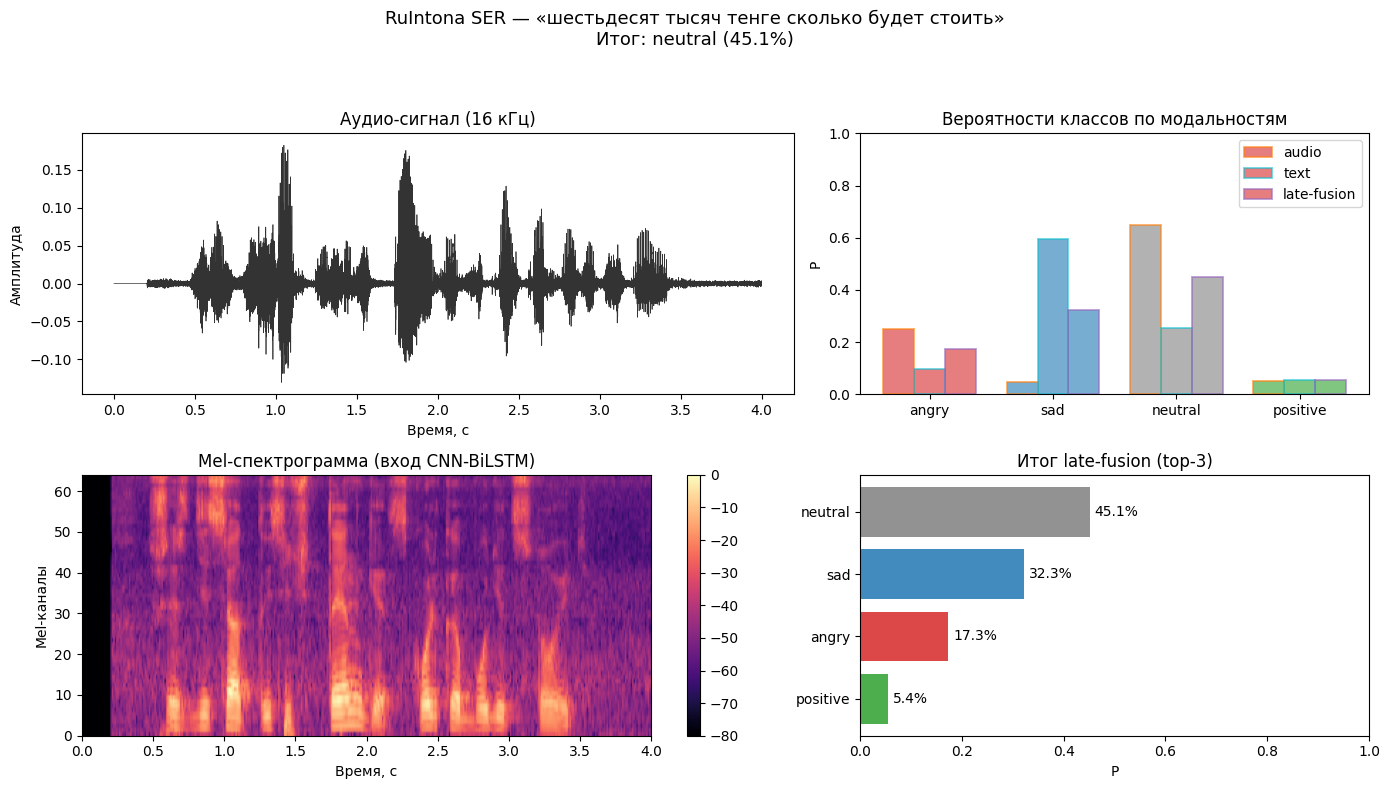

Сохранено: /home/natlis/PycharmProjects/dusha_new/ruintona/DEMO/results/demo_results.png


In [4]:
RESULT_DIR = DEMO_DIR / "results"
RESULT_DIR.mkdir(exist_ok=True)

waveform = load_audio(WAV_PATH)
mel = extract_mel(waveform)[0]  # (64, T)
duration = len(waveform) / SAMPLE_RATE
n_mels = mel.shape[0]

EMO_COLORS = {"angry": "#d62728", "sad": "#1f77b4", "neutral": "#7f7f7f", "positive": "#2ca02c"}
MOD_COLORS = {"audio": "#ff7f0e", "text": "#17becf", "late-fusion": "#9467bd"}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [1.4, 1]})

# Аудио-сигнал
axes[0, 0].plot(np.arange(len(waveform)) / SAMPLE_RATE, waveform, color="#333333", linewidth=0.5)
axes[0, 0].set_title("Аудио-сигнал (16 кГц)")
axes[0, 0].set_xlabel("Время, с")
axes[0, 0].set_ylabel("Амплитуда")

# Mel-спектрограмма
img = axes[1, 0].imshow(mel, aspect="auto", origin="lower", extent=[0, duration, 0, n_mels], cmap="magma")
axes[1, 0].set_title("Mel-спектрограмма (вход CNN-BiLSTM)")
axes[1, 0].set_xlabel("Время, с")
axes[1, 0].set_ylabel("Mel-каналы")
fig.colorbar(img, ax=axes[1, 0])

# Вероятности классов по модальностям (цвет баров = эмоция, обводка = модальность)
x = np.arange(len(TARGET_NAMES))
width = 0.25
for i, (name, probs) in enumerate(modalities.items()):
    vals = [probs[e] for e in TARGET_NAMES]
    axes[0, 1].bar(
        x + (i - 1) * width, vals, width,
        label=name, color=[EMO_COLORS[e] for e in TARGET_NAMES],
        alpha=0.6, edgecolor=MOD_COLORS[name], linewidth=1.4,
    )
axes[0, 1].set_title("Вероятности классов по модальностям")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(TARGET_NAMES)
axes[0, 1].set_ylabel("P")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()

# Итог late-fusion — top-3
top = dict(r_fusion["top3"])
emotions = list(reversed(list(top)))
vals = [top[e] for e in emotions]
axes[1, 1].barh(emotions, vals, color=[EMO_COLORS[e] for e in emotions], alpha=0.85)
for j, v in enumerate(vals):
    axes[1, 1].text(v + 0.01, j, f"{v:.1%}", va="center")
axes[1, 1].set_title("Итог late-fusion (top-3)")
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_xlabel("P")

fig.suptitle(
    f"RuIntona SER — «{SAMPLE_TEXT}»\nИтог: {r_fusion['emotion']} ({r_fusion['confidence']:.1%})",
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

fig.savefig(RESULT_DIR / "demo_results.png", dpi=110, bbox_inches="tight")
print("Сохранено:", RESULT_DIR / "demo_results.png")

## Вывод

Модель **late-fusion** объединяет аудио- и текстовую модальности (soft-voting).
Тот же результат можно получить из командной строки:

```bash
python ruintona/my_experiments/inference.py --model late-fusion \
    --audio ruintona/DEMO/data/001ce26c07c20eaa0d666b824c6c6924.wav \
    --text "шестьдесят тысяч тенге сколько будет стоить"

python ruintona/my_experiments/inference.py --model text --text "я очень рад сегодня"
python ruintona/my_experiments/inference.py --model audio --audio sample.wav
```